# AI-XRay · 01 — Exploración de datos (EDA) y manifiesto

**Clase 4 · Laboratorio Práctico Dirigido — Proyecto Final Independiente**
Unidad 3 · Módulo: Científico de Datos e Inteligencia Artificial Aplicada

### Objetivo de este notebook
1. Construir el **manifiesto** del dataset (ruta, etiqueta, paciente) a partir de las carpetas `train/`/`test/` originales.
2. Hacer un **EDA** básico: balance de clases, origen de las imágenes, tamaños.
3. **Confirmar el riesgo de fuga de datos** a nivel paciente entre `train/` y `test/` originales (con un ejemplo real del propio dataset).
4. Construir el **subconjunto balanceado de 2,000 imágenes** para la demo de clase.
5. Generar el **split propio 70/15/15**, agrupado por paciente, y verificar que no queda ningún paciente repartido entre dos splits.
6. Guardar el manifiesto final en `data/processed/`, listo para los siguientes notebooks.

> **Nota para el docente:** este es el notebook que se dicta en vivo primero. El punto más importante para remarcar en clase es la sección 3 (fuga de datos) -- es exactamente el tipo de decisión de arquitectura que después hay que justificar en el Executive Summary.

In [1]:
import sys
from pathlib import Path

# Este notebook vive en AI-XRay/notebooks/; agregamos AI-XRay/ al path para poder
# importar el paquete `src` (igual patrón en los 4 notebooks de este proyecto).
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from src.config import DATA_DIR, DEMO_SUBSET_PER_CLASS, MANIFEST_PATH, SPLIT_MANIFEST_PATH, SEED
from src.dataset import build_manifest, make_balanced_subset, split_manifest

print("Buscando el dataset en:", DATA_DIR)


Buscando el dataset en: C:\Users\juand\GitHub\M3-Cientifico-Datos-IA-Aplicada-DevSeniorCode\03_ia_aplicada_databricks_arquitecturas\clase_04_laboratorio_practico\archive (2)\Pediatric Chest X-ray Pneumonia


## 1. Manifiesto completo (train + test originales, juntos)

In [2]:
manifest = build_manifest(DATA_DIR)
print(f"Total de imágenes encontradas: {len(manifest)}")
manifest.head()


Total de imágenes encontradas: 5856


,path,filename,label,label_name,patient_id,origin_split
0,C:\Users\juand\GitHub\M3-Cientifico-Datos-IA-A...,IM-0115-0001.jpeg,0,NORMAL,normal_IM-0115-0001.jpeg,train
1,C:\Users\juand\GitHub\M3-Cientifico-Datos-IA-A...,IM-0117-0001.jpeg,0,NORMAL,normal_IM-0117-0001.jpeg,train
2,C:\Users\juand\GitHub\M3-Cientifico-Datos-IA-A...,IM-0119-0001.jpeg,0,NORMAL,normal_IM-0119-0001.jpeg,train
3,C:\Users\juand\GitHub\M3-Cientifico-Datos-IA-A...,IM-0122-0001.jpeg,0,NORMAL,normal_IM-0122-0001.jpeg,train
4,C:\Users\juand\GitHub\M3-Cientifico-Datos-IA-A...,IM-0125-0001.jpeg,0,NORMAL,normal_IM-0125-0001.jpeg,train


In [3]:
print("Por clase:")
print(manifest["label_name"].value_counts())
print()
print("Por carpeta de origen (informativo -- NO es el split que vamos a usar):")
print(manifest.groupby(["origin_split", "label_name"]).size())


Por clase:
label_name
PNEUMONIA    4273
NORMAL       1583
Name: count, dtype: int64

Por carpeta de origen (informativo -- NO es el split que vamos a usar):
origin_split  label_name
test          NORMAL         234
              PNEUMONIA      390
train         NORMAL        1349
              PNEUMONIA     3883
dtype: int64


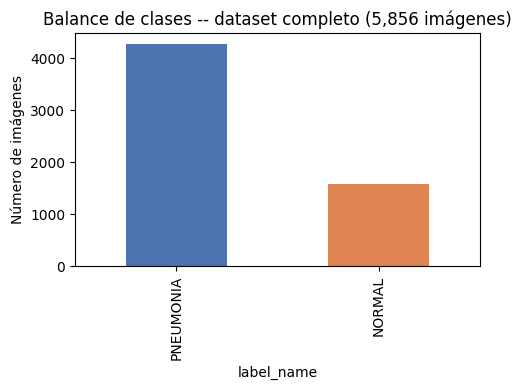

In [4]:
fig, ax = plt.subplots(figsize=(5, 4))
manifest["label_name"].value_counts().plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_title("Balance de clases -- dataset completo (5,856 imágenes)")
ax.set_ylabel("Número de imágenes")
plt.tight_layout()
plt.show()


## 2. Procesamiento masivo (paso simbólico con PySpark)

El reto de esta clase pide explícitamente **procesamiento masivo de datos en Databricks**.
Con 5,856 imágenes esto es simbólico (no se necesita un cluster), pero el código de abajo
es el MISMO que se usaría, sin cambios, sobre una carpeta de un Data Lake con cientos de
miles de imágenes -- ver `src/dataset.py::build_manifest_spark` y
`README.md` (sección "Fase 1 vs. Fase 2") para el resto del mapa de migración a Databricks.

Si PySpark no está instalado en tu entorno, esta celda se salta automáticamente (no es
un requisito para el resto del notebook, que sigue usando el manifiesto de pandas).

In [5]:
try:
    from src.dataset import build_manifest_spark
    manifest_spark = build_manifest_spark(DATA_DIR)
    print("Filas (Spark):", manifest_spark.count())
    manifest_spark.groupBy("label_name").count().show()
except ImportError:
    print("PySpark no está instalado en este entorno -- paso opcional, se omite.")
    print("El resto del notebook sigue funcionando con el manifiesto de pandas de arriba.")


Py4JJavaError: An error occurred while calling None.org.apache.spark.api.java.JavaSparkContext.
: java.lang.UnsupportedOperationException: getSubject is not supported
	at java.base/javax.security.auth.Subject.getSubject(Subject.java:277)
	at org.apache.hadoop.security.UserGroupInformation.getCurrentUser(UserGroupInformation.java:588)
	at org.apache.spark.util.Utils$.$anonfun$getCurrentUserName$1(Utils.scala:2446)
	at scala.Option.getOrElse(Option.scala:201)
	at org.apache.spark.util.Utils$.getCurrentUserName(Utils.scala:2446)
	at org.apache.spark.SparkContext.<init>(SparkContext.scala:339)
	at org.apache.spark.api.java.JavaSparkContext.<init>(JavaSparkContext.scala:59)
	at java.base/jdk.internal.reflect.DirectConstructorHandleAccessor.newInstance(DirectConstructorHandleAccessor.java:62)
	at java.base/java.lang.reflect.Constructor.newInstanceWithCaller(Constructor.java:499)
	at java.base/java.lang.reflect.Constructor.newInstance(Constructor.java:483)
	at py4j.reflection.Metho

## 3. Fuga de datos a nivel paciente (por qué no usamos el split original)

Las imágenes de `PNEUMONIA` siguen el patrón `personNNNN_{bacteria|virus}_MMMM.jpeg`. Si el
mismo `NNNN` aparece tanto en `train/` como en `test/` original, ese paciente tiene imágenes
en ambos lados -- evaluar con ese split sobreestimaría el desempeño real del modelo.

In [6]:
pneumonia = manifest[manifest["label_name"] == "PNEUMONIA"]
patient_splits = pneumonia.groupby("patient_id")["origin_split"].nunique()
patients_leaked = patient_splits[patient_splits > 1]

print(f"Pacientes (PNEUMONIA) con imágenes en train Y test original: {len(patients_leaked)}")
if len(patients_leaked) > 0:
    ejemplo = patients_leaked.index[0]
    print(f"Ejemplo real: '{ejemplo}' aparece en:")
    print(pneumonia[pneumonia['patient_id'] == ejemplo][['filename', 'origin_split']])


Pacientes (PNEUMONIA) con imágenes en train Y test original: 170
Ejemplo real: 'pneumonia_1' aparece en:
                     filename origin_split
2983  person1_bacteria_1.jpeg        train
2984  person1_bacteria_2.jpeg        train
5719    person1_virus_11.jpeg         test
5720    person1_virus_12.jpeg         test
5721    person1_virus_13.jpeg         test
5722     person1_virus_6.jpeg         test
5723     person1_virus_7.jpeg         test
5724     person1_virus_8.jpeg         test
5725     person1_virus_9.jpeg         test


**Conclusión:** el split `train/`/`test/` original no es confiable para evaluar el
modelo. Por eso, a partir de aquí, se descarta la columna `origin_split` para dividir los
datos y se construye un split propio (sección 5), agrupado por paciente.

## 4. Subconjunto balanceado para la demo de clase (~2,000 imágenes)

In [7]:
subset = make_balanced_subset(manifest, per_class=DEMO_SUBSET_PER_CLASS, seed=SEED)
print(f"Subconjunto: {len(subset)} imágenes")
print(subset["label_name"].value_counts())


Subconjunto: 2000 imágenes
label_name
PNEUMONIA    1000
NORMAL       1000
Name: count, dtype: int64


## 5. Split propio 70/15/15, agrupado por paciente

In [9]:
split = split_manifest(subset)
print(split.groupby(["split", "label_name"]).size())


split  label_name
test   NORMAL        150
       PNEUMONIA     147
train  NORMAL        700
       PNEUMONIA     702
val    NORMAL        150
       PNEUMONIA     151
dtype: int64


In [10]:
# Verificación: ningún paciente debe aparecer en más de un split.
leakage_check = split.groupby("patient_id")["split"].nunique()
n_leaked = (leakage_check > 1).sum()
print(f"Pacientes repartidos entre más de un split (debe ser 0): {n_leaked}")
assert n_leaked == 0, "¡Hay fuga de datos en el split! Revisa split_manifest()."
print("OK -- split sin fuga de datos a nivel paciente.")


Pacientes repartidos entre más de un split (debe ser 0): 0
OK -- split sin fuga de datos a nivel paciente.


## 6. Guardar el manifiesto final

In [11]:
MANIFEST_PATH.parent.mkdir(parents=True, exist_ok=True)
manifest.to_csv(MANIFEST_PATH, index=False)
split.to_csv(SPLIT_MANIFEST_PATH, index=False)
print("Guardado:")
print(" -", MANIFEST_PATH)
print(" -", SPLIT_MANIFEST_PATH)


Guardado:
 - C:\Users\juand\GitHub\M3-Cientifico-Datos-IA-Aplicada-DevSeniorCode\03_ia_aplicada_databricks_arquitecturas\clase_04_laboratorio_practico\AI-XRay\data\manifest.csv
 - C:\Users\juand\GitHub\M3-Cientifico-Datos-IA-Aplicada-DevSeniorCode\03_ia_aplicada_databricks_arquitecturas\clase_04_laboratorio_practico\AI-XRay\data\manifest_split.csv


## 🧪 Punto de decisión para tu Proyecto Final Independiente

Este notebook usó un subconjunto **balanceado** de 2,000 imágenes. Si vas a entrenar con
el **dataset completo** (5,856 imágenes, desbalanceado ~2.7:1 a favor de PNEUMONIA) para tu
proyecto propio:

1. Cambia `make_balanced_subset(...)` por el `manifest` completo directamente.
2. Usa `compute_balanced_class_weight()` (en `src/train.py`) al entrenar, en vez de
   depender del muestreo balanceado.
3. Documenta esta decisión (y su justificación) en tu Executive Summary.

### Cierre
Con el manifiesto y el split ya guardados, continúa en `02_preprocessing.ipynb`.